# Access Sentinel-3 in Analysis Mode

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-3** EOPF Zarr products in **analysis mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. 

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).  
For an example of the native mode, see the [Sentinel-3 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_3_native/).


- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

## Main Features of the Analysis Mode for Sentinel-3

Sentinel-3 products are provided on their **native grid**, where each pixel is defined by a latitude/longitude pair, forming a **2D curvilinear (irregular) grid**.

The analysis mode applies the [rectification algorithm in xcube-resampling](https://xcube-dev.github.io/xcube-resampling/guide/#3-rectification) to transform this irregular grid into a **regular (rectilinear) grid** with 1D latitude and longitude coordinates.

For **SLSTR** products, an additional terrain correction is applied during this process. This is necessary because the original geolocation accounts for Earth curvature, but not for terrain-induced variability due to topography. See the [SLSTR product description](https://sentiwiki.copernicus.eu/web/slstr-products) for details.

For **OLCI** products, no additional terrain correction is required, as it is already included in the Level-1 data. See the [OLCI Level-1 product description](https://sentiwiki.copernicus.eu/web/olci-products#OLCIProducts-L1BProducts-ObservationModeS3-OLCI-Products-L1B-OM) for details.

### Key Properties of Sentinel-3 Analysis Mode

- **Default mode** for the `"eopf-zarr"` backend  
- **Rectification**: converts the 2D curvilinear grid into a rectilinear grid  
- **Spatial subsetting** via the `bbox` argument  
- **Reprojection** to different CRS via the `crs` argument (default: WGS84, EPSG:4326)  
- **Flexible variable selection** using names or regular expressions  

For full details on available parameters, see the [Analysis Mode documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#analysis-mode) and, specifically for Sentinel-3, the [Sentinel-3 Analysis Mode guide](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-3).

---

## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import matplotlib.pyplot as plt
import pyproj
import pystac_client
import xarray as xr

---

## Open a Sentinel-3 OLCI L1 EFR

We begin with an example that accesses a Sentinel-3 OLCI L1 EFR product in **analysis mode**.

### Find a Sentinel-3 OLCI L1 EFR Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-efr) to search for a Sentinel-3 OLCI Level-1 EFR tile.

In [3]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-olci-l1-efr"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=["2026-03-13", "2026-03-13"],
    ).items()
)
items

[<Item id=S3B_OL_1_EFR____20260313T100048_20260313T100348_20260313T120352_0179_117_350_2160_ESA_O_NR_004>,
 <Item id=S3B_OL_1_EFR____20260313T100048_20260313T100348_20260314T100820_0180_117_350_2160_ESA_O_NT_004>]

In [4]:
item = items[0]

### Open Sentinel-3 OLCI L1 EFR with default parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method. Since this is the default, the `op_mode` parameter does not need to be specified.  

The following cell returns a **lazy dataset**, with all bands recifified to a regular grid. If no `resolution` is given, the spatial resolution is estimated from the 2D latitude and longitude grids.

In [4]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={}
)
ds

<xarray.Dataset> Size: 4GB
Dimensions:        (lon: 5157, lat: 4791)
Coordinates:
  * lon            (lon) float64 41kB -4.786 -4.782 -4.778 ... 15.21 15.22 15.22
  * lat            (lat) float64 38kB 52.46 52.46 52.46 ... 39.56 39.56 39.55
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa02_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa03_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa04_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa05_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa06_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    ...             ...
    oa16_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa17_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa18_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa19_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa20_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa21_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (9)

As an example, we plot the **red band** (`oa08_radiance`), which triggers data loading, rectification, and visualization of the rectified result.

> **Note:** To speed up rendering of large datasets in Matplotlib, we plot the data at a lower resolution (every 4th pixel).

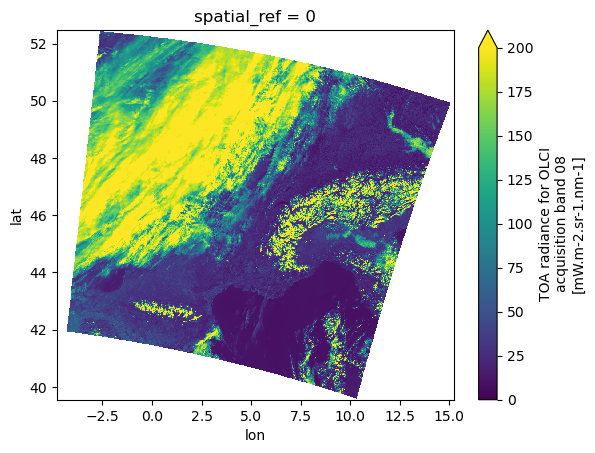

In [5]:
ds.oa08_radiance[::4, ::4].plot(vmin=0., vmax=200.)

### Spatial Resampling, Subsetting and Reprojection

We can also change the resolution and display only a subset of the data by specifying the `bbox` argument, as shown below.

In [5]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    resolution=0.01,
    bbox=[5, 40, 15, 48],
    chunks={},
)
ds

<xarray.Dataset> Size: 134MB
Dimensions:        (lon: 1000, lat: 800)
Coordinates:
  * lon            (lon) float64 8kB 5.005 5.015 5.025 ... 14.97 14.98 14.99
  * lat            (lat) float64 6kB 47.99 47.98 47.97 ... 40.03 40.02 40.01
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa02_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa03_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa04_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa05_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa06_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    ...             ...
    oa16_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa17_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa18_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa19_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa20_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa21_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
Attributes: (9)

As an example, we plot again the red band (`oa08_radiance`).

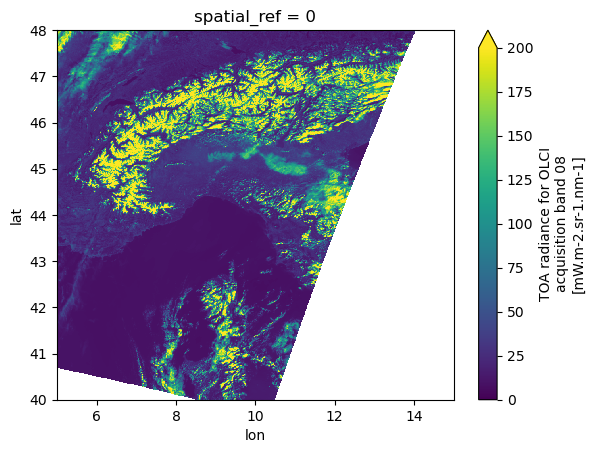

In [6]:
ds.oa08_radiance.plot(vmin=0., vmax=200.)

We can request the same area in **LAEA CRS** by specifying `crs="EPSG:3035"`. Note that both the `resolution` and `bbox` must be provided in the CRS units.

In [7]:
bbox = [5, 40, 15, 48]
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
bbox_crs = transformer.transform_bounds(*bbox) 
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    crs="EPSG:3035", 
    resolution=1000,
    bbox=bbox_crs,
    chunks={},
)
ds

<xarray.Dataset> Size: 130MB
Dimensions:        (x: 858, y: 900)
Coordinates:
  * x              (x) float64 7kB 3.893e+06 3.894e+06 ... 4.749e+06 4.75e+06
  * y              (y) float64 7kB 2.778e+06 2.777e+06 ... 1.88e+06 1.879e+06
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa02_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa03_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa04_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa05_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa06_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    ...             ...
    oa16_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa17_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa18_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa19_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa20_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa21_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
Attributes: (9)

We plot the red band (`oa08_radiance`).

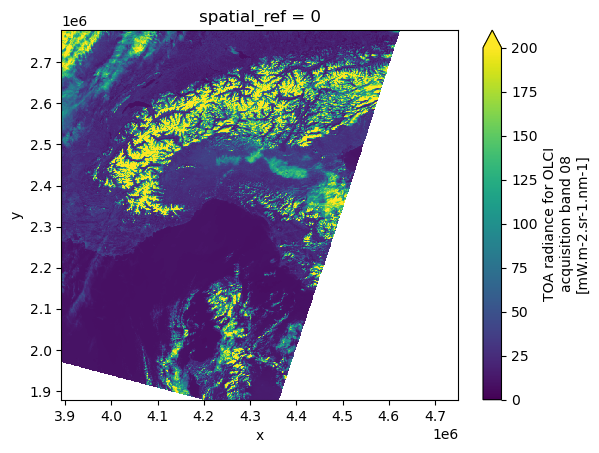

In [8]:
ds.oa08_radiance.plot(vmin=0., vmax=200.)

---

## Open a Sentinel-3 OLCI L1 ERR

We now access a Sentinel-3 OLCI L1 ERR product in **analysis mode**. The data access methods shown above apply equally to Sentinel-3 OLCI L1 EFR.

### Find a Sentinel-3 OLCI L1 ERR Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-err) to search for available Sentinel-3 OLCI L1 ERR tiles.

In [9]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-olci-l1-err"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=["2026-03-23", "2026-03-23"],
    ).items()
)
items

[<Item id=S3A_OL_1_ERR____20260323T093015_20260323T101415_20260324T104040_2640_137_250______PS1_O_NT_004>,
 <Item id=S3A_OL_1_ERR____20260323T093015_20260323T101415_20260323T113534_2640_137_250______PS1_O_NR_004>]

In [10]:
item = items[0]

### Open Sentinel-3 OLCI L1 ERR with Default Parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method, as before.  

If no spatial subsetting is applied via the `bbox` argument, the full dataset (typically covering half an orbit) is rectified to a regular grid in the WGS84 coordinate reference system.

In [11]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    resolution=0.01,
    bbox=[-0, 20, 40, 60],
    chunks={},
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:        (lon: 4000, lat: 4000)
Coordinates:
  * lon            (lon) float64 32kB 0.005 0.015 0.025 ... 39.97 39.98 39.99
  * lat            (lat) float64 32kB 59.99 59.98 59.97 ... 20.03 20.02 20.01
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa02_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa03_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa04_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa05_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa06_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    ...             ...
    oa16_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa17_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa18_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa19_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa20_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa21_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (8)

As an example, we plot the **red band** (`oa08_radiance`), which triggers data loading, rectification, and visualization of the rectified result.

> **Note:** To speed up rendering of large datasets in Matplotlib, we plot the data at a lower resolution (every 10th pixel).

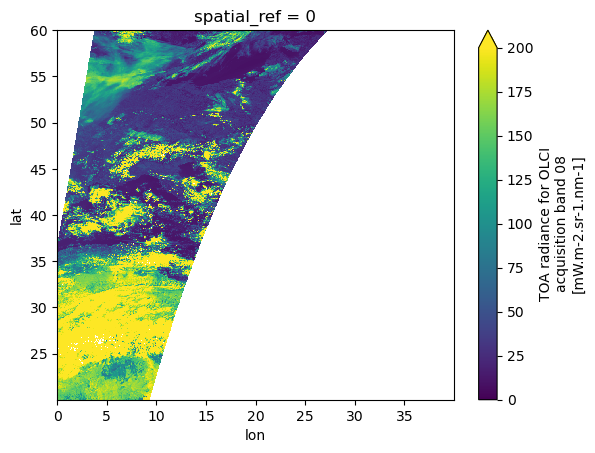

In [12]:
ds.oa08_radiance[::4, ::4].plot(vmin=0., vmax=200.)

---

## Open a Sentinel-3 SLSTR Level-2 LST

We now access a Sentinel-3 SLSTR Level-2 LST product in **analysis mode**. The data access methods shown above apply equally to Sentinel-3 SLSTR Level-2 LST.

### Find a Sentinel-3 SLSTR Level-2 LST Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst) to search for a Sentinel-3 SLSTR Level-2 LST tile.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-slstr-l2-lst"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=["2026-03-13", "2026-03-13"],
    ).items()
)
items

[<Item id=S3B_SL_2_LST____20260313T212343_20260313T212643_20260313T235949_0179_117_357_0720_ESA_O_NR_004>,
 <Item id=S3B_SL_2_LST____20260313T212343_20260313T212643_20260315T051508_0179_117_357_0720_ESA_O_NT_004>,
 <Item id=S3B_SL_2_LST____20260313T100048_20260313T100348_20260314T174003_0180_117_350_2160_ESA_O_NT_004>]

In [3]:
item = items[0]

### Open Sentinel-3 SLSTR Level-2 LST with Default Parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method, as before.

In [4]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
)
ds

<xarray.Dataset> Size: 20MB
Dimensions:      (lon: 1676, lat: 1482)
Coordinates:
  * lon          (lon) float64 13kB -9.567 -9.554 -9.54 ... 12.8 12.82 12.83
  * lat          (lat) float64 12kB 54.45 54.44 54.43 ... 41.16 41.15 41.14
    spatial_ref  int64 8B ...
Data variables:
    lst          (lat, lon) float64 20MB dask.array<chunksize=(1482, 1676), meta=np.ndarray>
Attributes: (16)

As an example, we plot the **LST array**, which triggers data loading, rectification, and visualization of the rectified result.

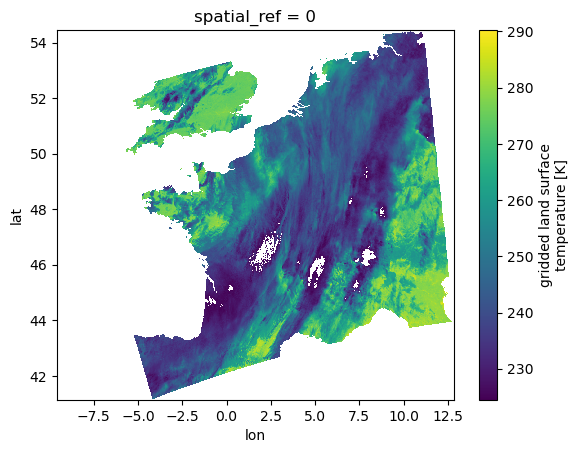

In [5]:
ds.lst.plot()

---

## Open Sentinel-3 SLSTR Level-1B RBT

We now access a Sentinel-3 SLSTR Level-1B RBT product in **analysis mode**. 

The SLSTR instrument provides observations from two viewing geometries: **nadir** and **oblique** (forward view). These are designed to improve atmospheric correction and enable more accurate surface measurements.

Accordingly, many variables in the RBT product are available in pairs:
- `*_an` → **nadir view** (e.g. `s1_radiance_an`)
- `*_ao` → **oblique view** (e.g. `s1_radiance_ao`)

### Find a Sentinel-3 SLSTR Level-1B RBT Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l1-rbt) to search for a Sentinel-3 SLSTR Level-1B RBT tile.

In [6]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-slstr-l1-rbt"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=["2026-03-13", "2026-03-13"],
    ).items()
)
items

[<Item id=S3B_SL_1_RBT____20260313T212343_20260313T212643_20260313T235116_0179_117_357_0720_ESA_O_NR_004>,
 <Item id=S3B_SL_1_RBT____20260313T212343_20260313T212643_20260315T025651_0179_117_357_0720_ESA_O_NT_004>,
 <Item id=S3B_SL_1_RBT____20260313T100048_20260313T100348_20260313T122107_0179_117_350_2160_ESA_O_NR_004>,
 <Item id=S3B_SL_1_RBT____20260313T100048_20260313T100348_20260314T152444_0180_117_350_2160_ESA_O_NT_004>]

In [7]:
item = items[2]

In [4]:
item

<Item id=S3B_SL_1_RBT____20260313T100048_20260313T100348_20260313T122107_0179_117_350_2160_ESA_O_NR_004>

### Open Sentinel-3 SLSTR Level-1B RBT with Default Parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method, as before.

In [12]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
    bbox=[10, 43, 17, 48],
    variables=["s1_radiance_an", "s1_radiance_ao"],
)
ds

<xarray.Dataset> Size: 19MB
Dimensions:         (lon: 1093, lat: 1114)
Coordinates:
  * lon             (lon) float64 9kB 10.0 10.01 10.02 ... 16.99 16.99 17.0
  * lat             (lat) float64 9kB 48.0 48.0 47.99 47.99 ... 43.01 43.01 43.0
    spatial_ref     int64 8B ...
Data variables:
    s1_radiance_an  (lat, lon) float64 10MB dask.array<chunksize=(1114, 1093), meta=np.ndarray>
    s1_radiance_ao  (lat, lon) float64 10MB dask.array<chunksize=(1114, 1093), meta=np.ndarray>
Attributes: (90)

As an example, we plot the nadir and oblique views of the S1 thermal channel side by side.

CPU times: user 1.8 s, sys: 270 ms, total: 2.07 s
Wall time: 3.11 s


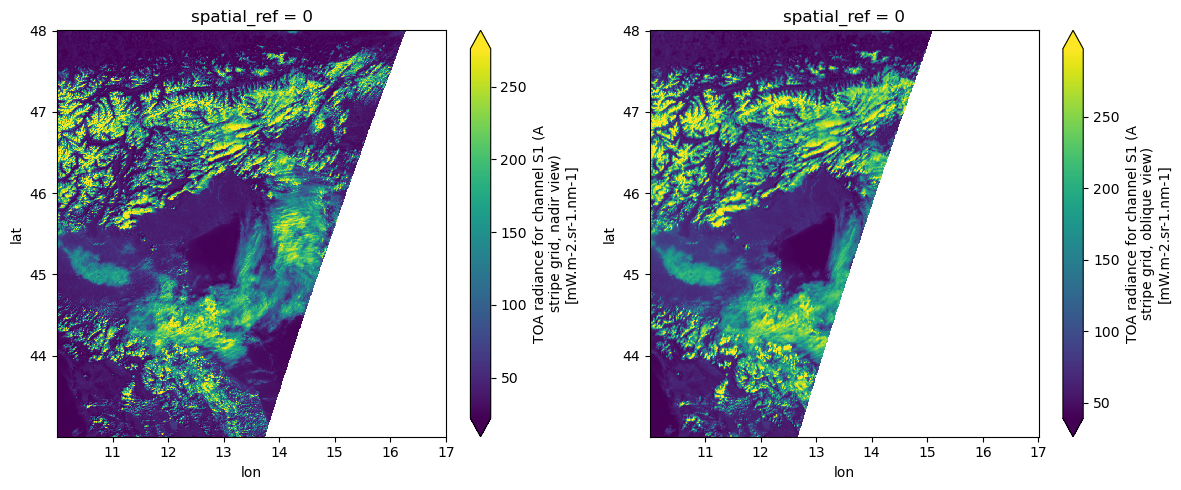

In [13]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.s1_radiance_an.plot(ax=ax[0], robust=True)
ds.s1_radiance_ao.plot(ax=ax[1], robust=True)
plt.tight_layout()

Other Sentinel-3 products can be accessed using the same approach and are therefore not shown here in detail.

---

## Conclusion

This notebook demonstrates how to access Sentinel-2 EOPF Zarr samples in **analysis mode** using the **xarray-eopf** plugin. The key takeaways are:

- **Analysis mode** is the default `op_mode`.
- In analysis mode, Sentinel-3 spectral bands are rectified to a rectilinear grid  
- Data can be accessed lazily at a **user-defined resolution, bounding box, and CRS**, enabling flexible resampling, subsetting, and reprojection.

> **Note:** This notebook only covers **analysis mode** for Sentinel-3. To learn more about **native mode**, see the [Sentinel-3 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_3_native/).

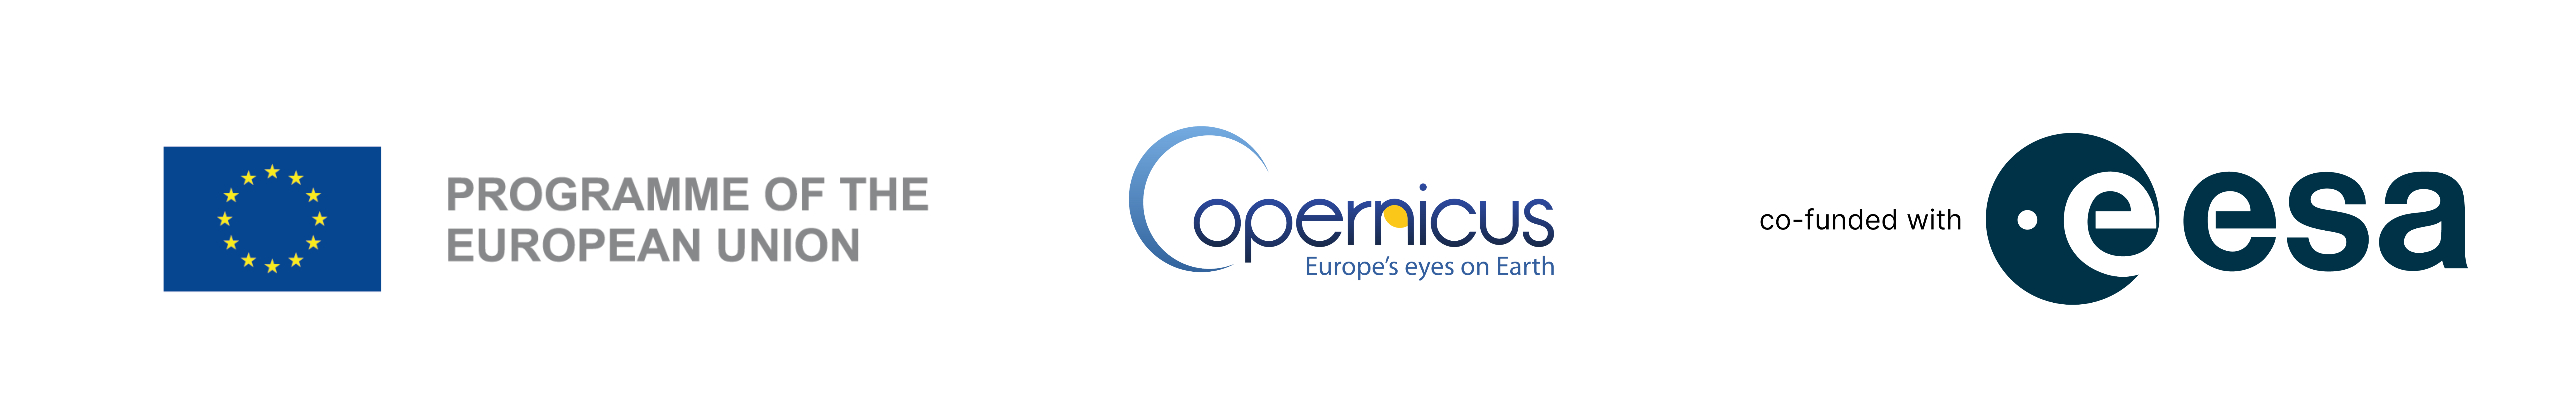